# Strawberries and Faces ;-)

This is a step by step working example to understand basics image processing function using OpenCV.

It is mostly a bugfix, enhanced wih a few comments, of the original notebook made by Alex Louden and avalable here <https://github.com/alexlouden/strawberries>. I also integrated pieces of code from pyimagesearch <https://www.pyimagesearch.com/2020/04/06/blur-and-anonymize-faces-with-opencv-and-python/>.

In [3]:
!pip install opencv-python

In [4]:
%matplotlib inline
import cv2
import matplotlib
from matplotlib import colors
from matplotlib import pyplot as plt
import numpy as np
import os

## This code is to be used to toggle on/off :Google Colab

In [10]:
use_google_colab=False
if use_google_colab:
  from google.colab import drive
  drive.mount('/content/gdrive/')
  filepath='/content/gdrive/MyDrive/Colab_Notebooks/Image_Analysis_Part1/'
else:
  filepath='C:/Users/Cesar/Desktop/Master/Deep Learning/Image_Analysis_Part1/'
print(filepath)

C:/Users/Cesar/Desktop/Master/Deep Learning/Image_Analysis_Part1/


## Some usefull functions for plotting

As the image has a certain physical resolution when displaying on a bigger frame we need interpolation, we select as default intepolator the nearest neighboor one. To plot an image which is stored in HSV format we need to convert it in RGB first.

In [6]:
def show(image):
    # Figure size in inches
    plt.figure(figsize=(8, 8))
    # Show image, with nearest neighbour interpolation
    plt.imshow(image, interpolation='nearest')
    
#HSV to RGB    
def show_hsv(hsv):
    rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    show(rgb)
# Grayscale    
def show_mask(mask):
    plt.figure(figsize=(8, 8))
    plt.imshow(mask, cmap='gray')

#RGB and Gray     
def overlay_mask(mask, image):
    rgb_mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
    img = cv2.addWeighted(rgb_mask, 0.5, image, 0.5, 0)
    show(img)

## Image reading and some statistics of pixels

OpenCv knows already how to deal with different image file formats, the only thing you need to keep in mind is that by default it reads the image in memo
ry according to the BGR ordering and not the more commo RGB we are used to.

In [11]:
image = cv2.imread(filepath+'strawberries.jpg')

In [12]:
print(image.shape)
print("Num pixels:",image.shape[0]*image.shape[1])

(1414, 2121, 3)
Num pixels: 2999094


In [13]:
image[0,0]

array([ 67, 121,  92], dtype=uint8)

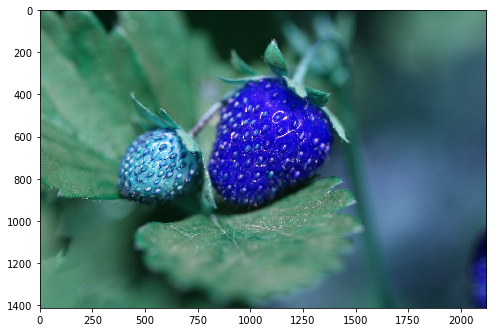

In [14]:
show(image)

In [15]:
# Convert from BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to a third of the size
image = cv2.resize(image, None, fx=1/3, fy=1/3)

(471, 707, 3)
[210  16  42]
[0.82352941 0.0627451  0.16470588]
[18 32  7]


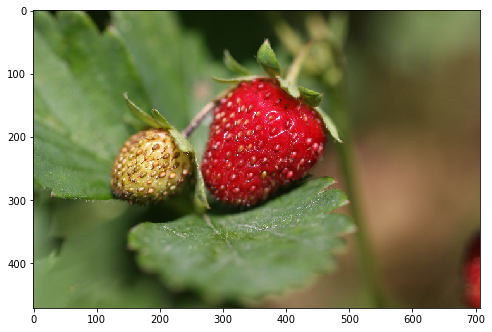

In [16]:
print(image.shape)
print(image[200,400])
print(image[200,400]/255)
print(image[35,350])
show(image)

In [17]:
import pandas as pd
m,n,r = image.shape
arr = image.reshape(m*n, -1)
df = pd.DataFrame(arr, columns=['r', 'g', 'b'])
df.describe()

,r,g,b
count,332997.000000,332997.000000,332997.000000
mean,110.133374,103.448590,60.705679
std,43.825622,43.252312,32.481965
min,8.000000,0.000000,0.000000
25%,84.000000,74.000000,36.000000
50%,109.000000,108.000000,59.000000
75%,131.000000,138.000000,83.000000
max,255.000000,255.000000,255.000000


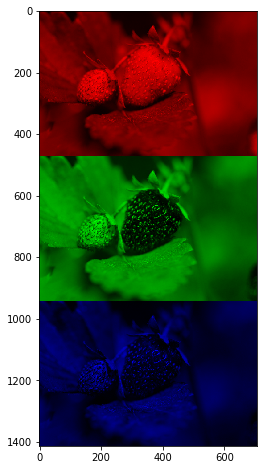

In [55]:
# Show Red/Green/Blue
images = []
for i in [0, 1, 2]:
    colour = image.copy()
    if i != 0: colour[:,:,0] = 0
    if i != 1: colour[:,:,1] = 0
    if i != 2: colour[:,:,2] = 0
    images.append(colour)
    
show(np.vstack(images))

## Channel histograms and color segmentation

Image segmentation is a common practice in Image Analysis and it is about the separation of relevant information from irrelevant one. At pixel level it means to mark strawberry pixels with 1 and non strawberry pixels with 0. 

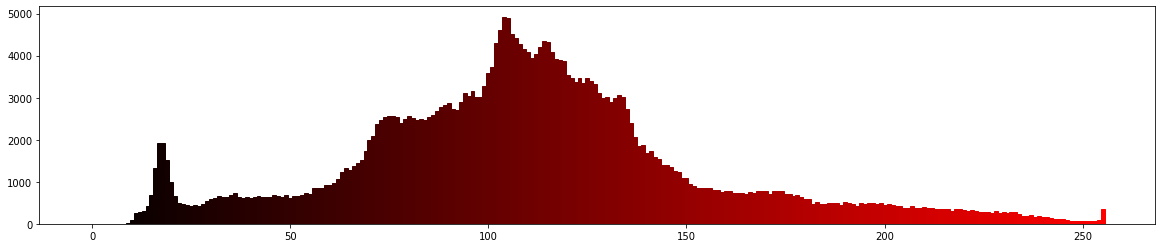

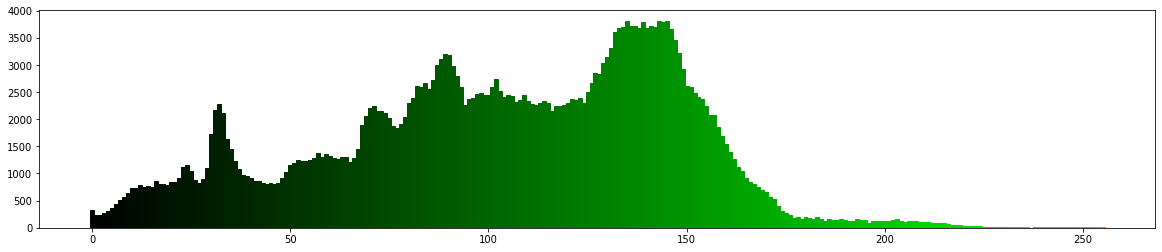

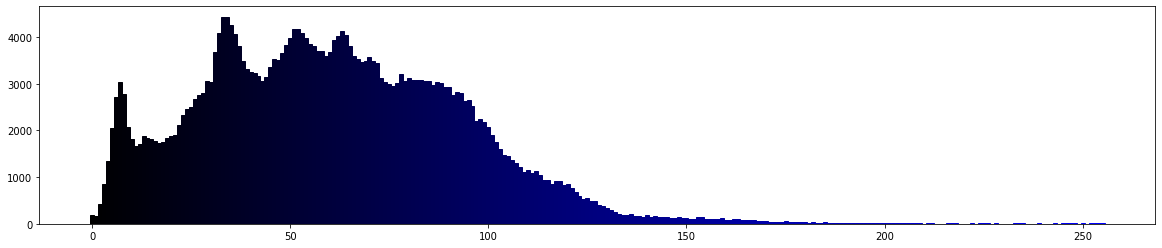

In [ ]:
def show_rgb_hist(image):
    colours = ('r','g','b')
    for i, c in enumerate(colours):
        plt.figure(figsize=(20, 4))
        histr = cv2.calcHist([image], [i], None, [256], [0, 256])
#        plt.plot(histr, color=c, lw=2)
        
        if c == 'r': colours = [((i/256, 0, 0)) for i in range(0, 256)]
        if c == 'g': colours = [((0, i/256, 0)) for i in range(0, 256)]
        if c == 'b': colours = [((0, 0, i/256)) for i in range(0, 256)]
       
        plt.bar(range(0, 256), histr[:,0], color=colours, edgecolor=colours, width=1)
#         plt.xlim([0, 256])

        plt.show()
    
show_rgb_hist(image)

In [ ]:
#TODO: Histogram Equalization 

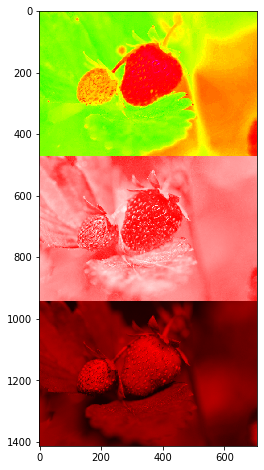

In [56]:
# Convert from RGB to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

images = []
for i in [0, 1, 2]:
    colour = hsv.copy()
    if i != 0: colour[:,:,0] = 0
    if i != 1: colour[:,:,1] = 255
    if i != 2: colour[:,:,2] = 255
    images.append(colour)
    
hsv_stack = np.vstack(images)
rgb_stack = cv2.cvtColor(hsv_stack, cv2.COLOR_HSV2RGB)
show(rgb_stack)

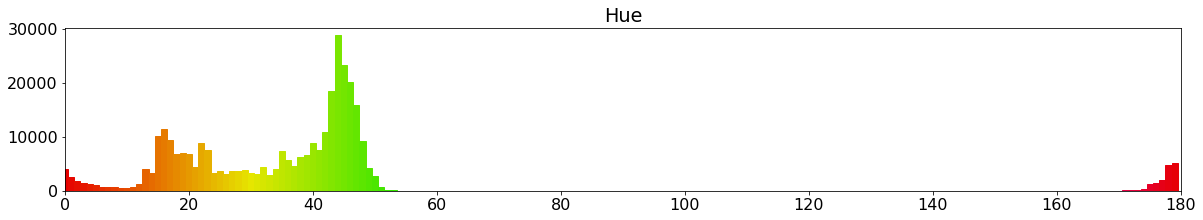

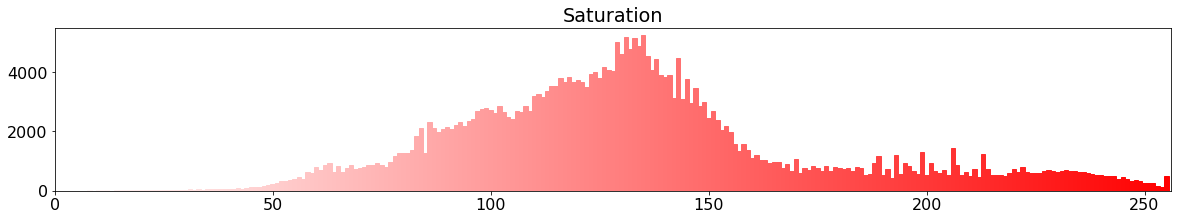

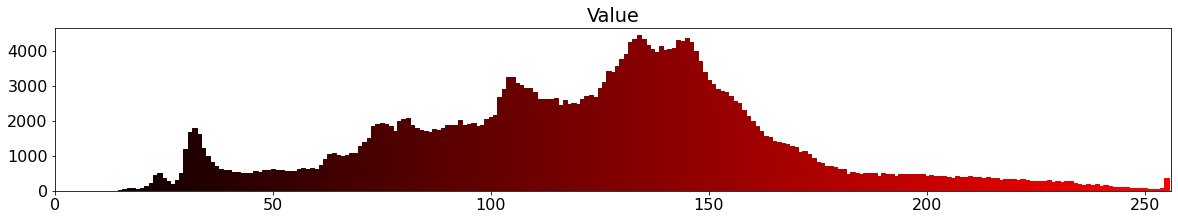

In [57]:
matplotlib.rcParams.update({'font.size': 16})

# Hue is described with the words we normally think of as describing color: 
# red, purple, blue, etc. Value (lightness) describes overall intensity to how light or dark a color is.
# It is the only dimension of color that may exist by itself. Chroma (saturation) may be defined as 
# the strength or dominance of the hue.
def show_hsv_hist(image):
    # Hue
    plt.figure(figsize=(20, 3))
    histr = cv2.calcHist([image], [0], None, [180], [0, 180])
    plt.xlim([0, 180])
    colours = [colors.hsv_to_rgb((i/180, 1, 0.9)) for i in range(0, 180)]
    plt.bar(range(0, 180), histr[:,0], color=colours, edgecolor=colours, width=1)
    plt.title('Hue')

    # Saturation
    plt.figure(figsize=(20, 3))
    histr = cv2.calcHist([image], [1], None, [256], [0, 256])
    plt.xlim([0, 256])

    colours = [colors.hsv_to_rgb((0, i/256, 1)) for i in range(0, 256)]
    plt.bar(range(0, 256), histr[:,0], color=colours, edgecolor=colours, width=1)
    plt.title('Saturation')

    # Value
    plt.figure(figsize=(20, 3))
    histr = cv2.calcHist([image], [2], None, [256], [0, 256])
    plt.xlim([0, 256])

    colours = [colors.hsv_to_rgb((0, 1, i/256)) for i in range(0, 256)]
    plt.bar(range(0, 256), histr[:,0], color=colours, edgecolor=colours, width=1)
    plt.title('Value')
    
show_hsv_hist(hsv)

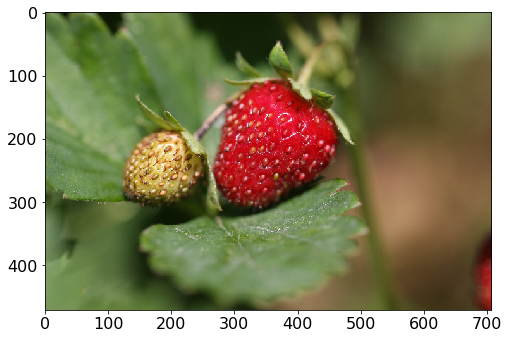

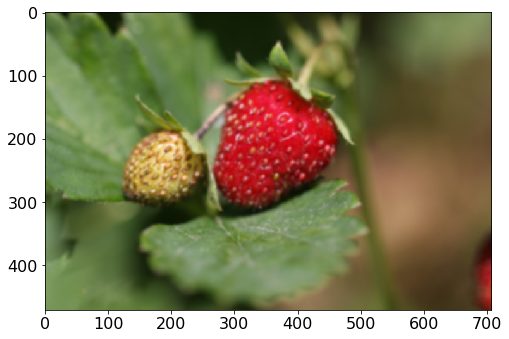

In [58]:
# Blur image slightly
image_blur = cv2.GaussianBlur(image, (7, 7), 0)
show(image)
show(image_blur)

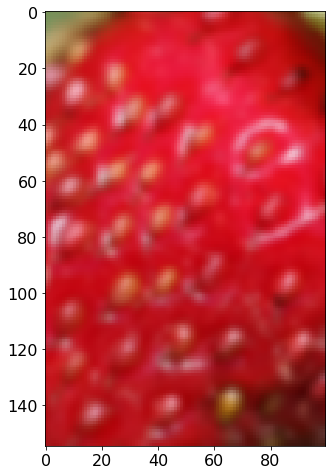

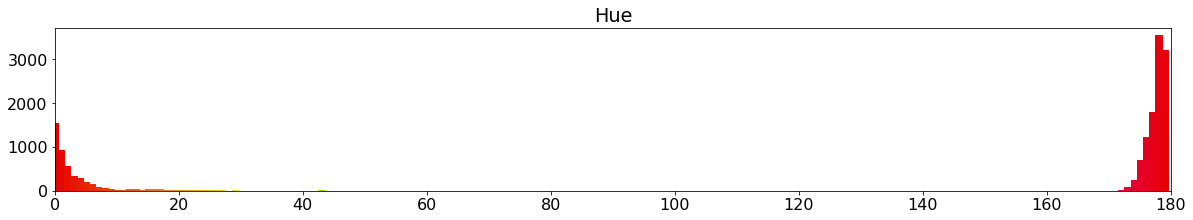

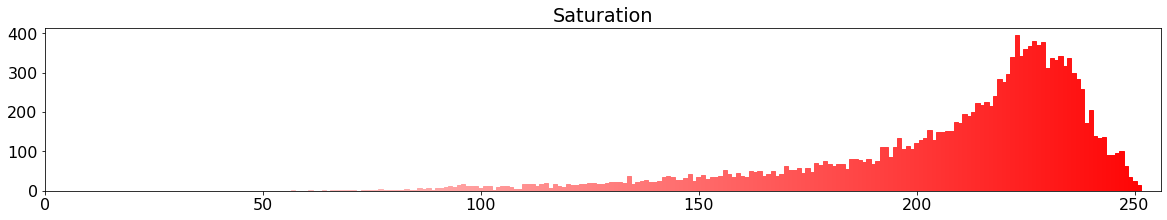

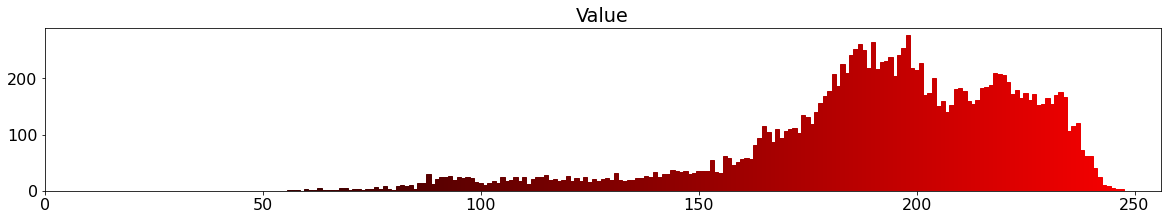

In [59]:
image_cropped = image_blur[120:275, 300:400]
show(image_cropped)
image_cropped_hsv = cv2.cvtColor(image_cropped, cv2.COLOR_RGB2HSV)
show_hsv_hist(image_cropped_hsv)

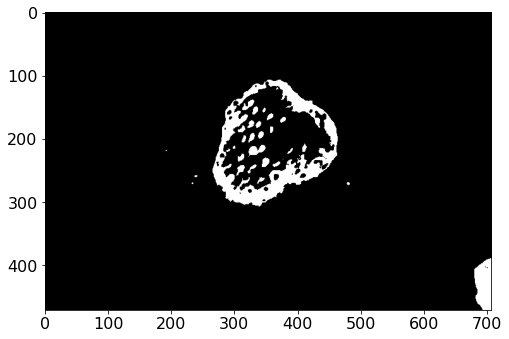

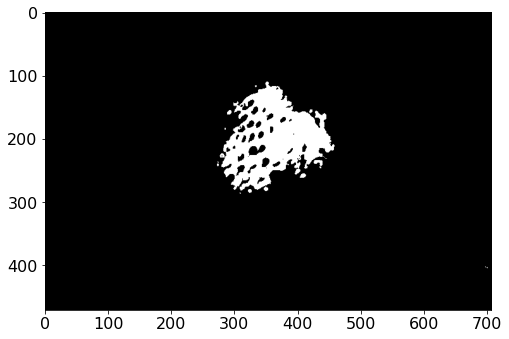

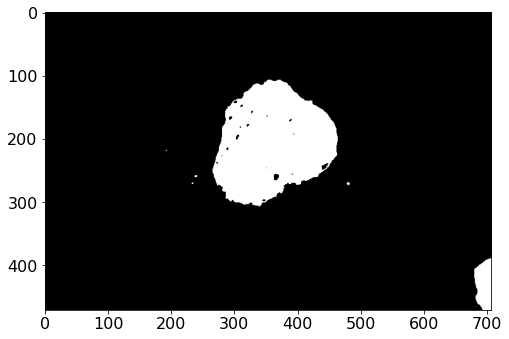

In [60]:
image_blur_hsv = cv2.cvtColor(image_blur, cv2.COLOR_RGB2HSV)

# 0-10 hue
min_red = np.array([0, 100, 80])
max_red = np.array([10, 255, 255])
image_red1 = cv2.inRange(image_blur_hsv, min_red, max_red)

# 170-180 hue
min_red2 = np.array([170, 100, 80])
max_red2 = np.array([180, 255, 255])
image_red2 = cv2.inRange(image_blur_hsv, min_red2, max_red2)

show_mask(image_red1)
show_mask(image_red2)
image_red = image_red1 + image_red2
show_mask(image_red)

In [61]:
image_red

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255]], dtype=uint8)

## Morphological operators and object detection

So far we have operated ar the level of pixels, let's now move to morphological operators looking at the neghborhood of pixels. In OpenCV this is obtaned by using morphological operators and the Opening and Closing operations.  

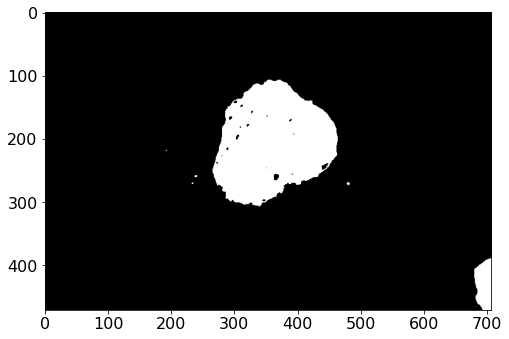

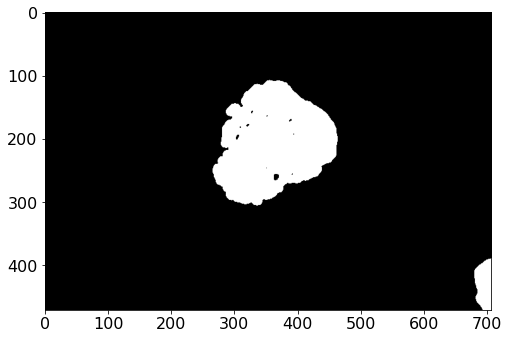

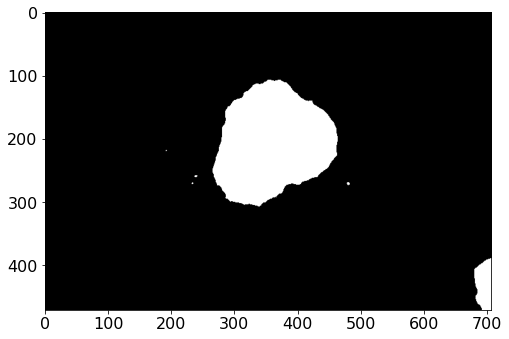

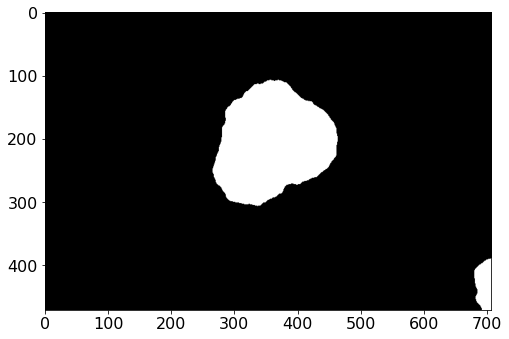

In [62]:
# Clean up
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))

show_mask(image_red)

# image_red_eroded = cv2.morphologyEx(image_red, cv2.MORPH_ERODE, kernel)
# show_mask(image_red_eroded)

# image_red_dilated = cv2.morphologyEx(image_red, cv2.MORPH_DILATE, kernel)
# show_mask(image_red_dilated)

image_red_opened = cv2.morphologyEx(image_red, cv2.MORPH_OPEN, kernel)
show_mask(image_red_opened)

# Fill small gaps
image_red_closed = cv2.morphologyEx(image_red, cv2.MORPH_CLOSE, kernel)
show_mask(image_red_closed)

# Remove specks
image_red_closed_then_opened = cv2.morphologyEx(image_red_closed, cv2.MORPH_OPEN, kernel)
show_mask(image_red_closed_then_opened)

The easiest object detector is the so called blob detector which extract connected components from the mask obtained after thresholding. This algorthm returns all the connected components from the image so we can select the bst one according to some criteria, e.g., the biggest cnnected component.

Total number of blobs: 2


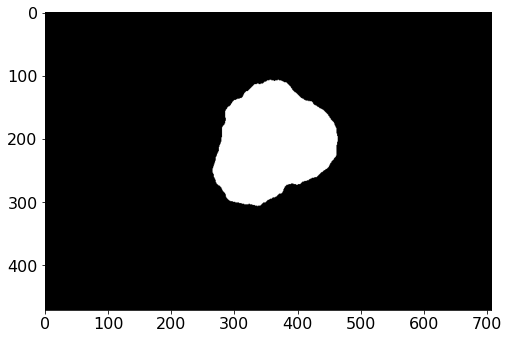

In [67]:
def find_biggest_contour(image):
    
    # Copy to prevent modification
    image = image.copy()
    contours, hierarchy = cv2.findContours(image, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    print('Total number of blobs:',len(contours))

    # Isolate largest contour
    contour_sizes = [(cv2.contourArea(contour), contour) for contour in contours]
    biggest_contour = max(contour_sizes, key=lambda x: x[0])[1]
 
    mask = np.zeros(image.shape, np.uint8)
    cv2.drawContours(mask, [biggest_contour], -1, 255, -1)
    return biggest_contour, mask

big_contour, red_mask = find_biggest_contour(image_red_closed_then_opened)
show_mask(red_mask)

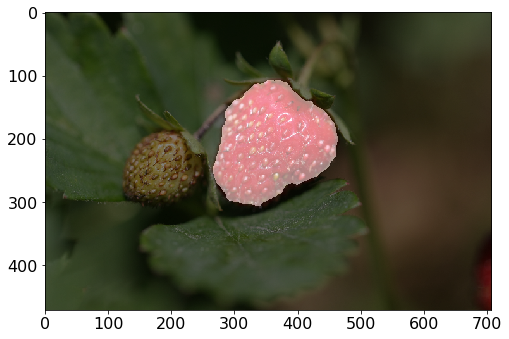

In [64]:
overlay_mask(red_mask, image)

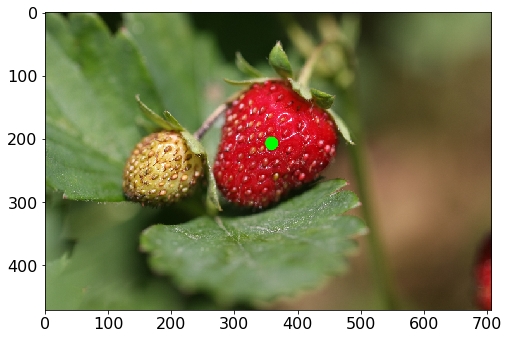

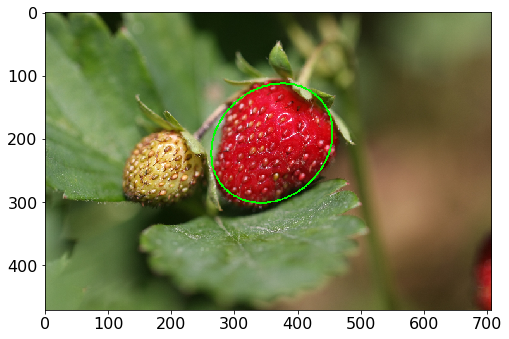

In [68]:
# Centre of mass
moments = cv2.moments(red_mask)
centre_of_mass = int(moments['m10'] / moments['m00']), int(moments['m01'] / moments['m00'])
image_with_com = image.copy()
cv2.circle(image_with_com, centre_of_mass, 10, (0, 255, 0), -1, cv2.LINE_AA)
show(image_with_com)

# Bounding ellipse
image_with_ellipse = image.copy()
ellipse = cv2.fitEllipse(big_contour)
cv2.ellipse(image_with_ellipse, ellipse, (0,255,0), 2)
show(image_with_ellipse)

Let's assume we whant all the strawberries ...

In [ ]:
#TODO: extract all straberries from all examples

## From strawberries to faces

As funny as it might be, searching for strawberies might not be so interesting, what if we want to find faces instead?

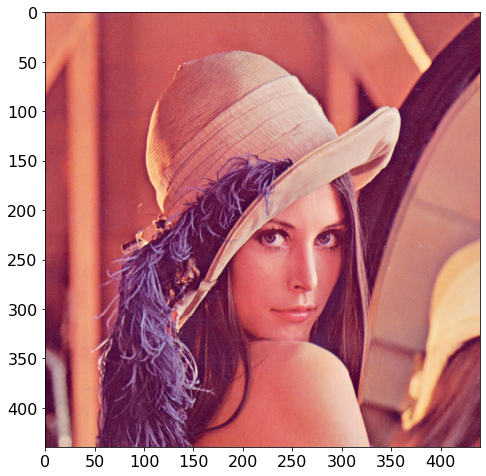

In [71]:
image = cv2.imread(filepath+'Lenna.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
show(image)

In [18]:
face_cascade = cv2.CascadeClassifier(filepath+'haarcascade_frontalface_default.xml')
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

In [76]:
faces = face_cascade.detectMultiScale(gray, 1.1, 4)
print('Total number of faces:',len(faces))

Total number of faces: 1


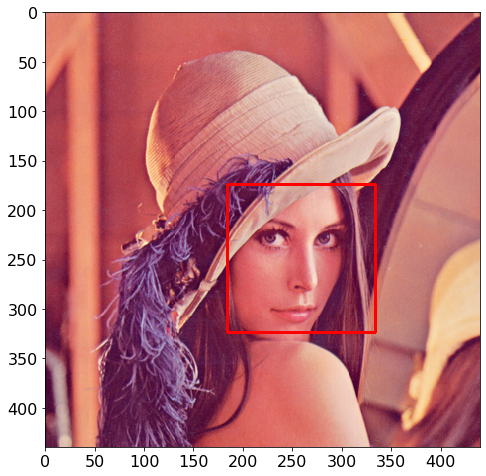

In [77]:
# Draw rectangle around the faces
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

show(image)
# Display the output
#cv2.imshow("img", image)
#cv2.waitKey()
#cv2.destroyWindow("img")

4


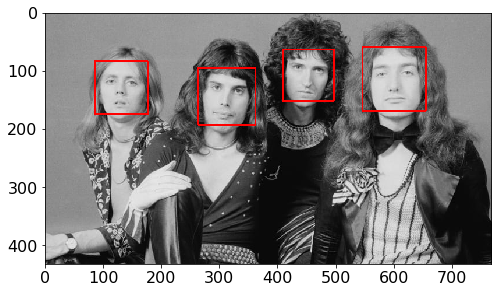

In [79]:
gray =cv2.imread(filepath+'queen.jpg')
faces = face_cascade.detectMultiScale(gray, 1.1, 4)
print(len(faces))

# Draw rectangle around the faces
for (x, y, w, h) in faces:
    cv2.rectangle(gray, (x, y), (x + w, y + h), (255, 0, 0), 2)

show(gray)

In [80]:
def anonymize_face_simple(image, factor=3.0):
    # automatically determine the size of the blurring kernel based
    # on the spatial dimensions of the input image
    (h, w) = image.shape[:2]
    kW = int(w / factor)
    kH = int(h / factor)

    # ensure the width of the kernel is odd
    if kW % 2 == 0:
        kW -= 1

    # ensure the height of the kernel is odd
    if kH % 2 == 0:
        kH -= 1

    # apply a Gaussian blur to the input image using our computed
    # kernel size
    return cv2.GaussianBlur(image, (kW, kH), 0)

In [81]:
def anonymize_face_pixelate(image, blocks=3):
    # divide the input image into NxN blocks
    (h, w) = image.shape[:2]
    xSteps = np.linspace(0, w, blocks + 1, dtype="int")
    ySteps = np.linspace(0, h, blocks + 1, dtype="int")

    # loop over the blocks in both the x and y direction
    for i in range(1, len(ySteps)):
        for j in range(1, len(xSteps)):
            # compute the starting and ending (x, y)-coordinates
            # for the current block
            startX = xSteps[j - 1]
            startY = ySteps[i - 1]
            endX = xSteps[j]
            endY = ySteps[i]

            # extract the ROI using NumPy array slicing, compute the
            # mean of the ROI, and then draw a rectangle with the
            # mean RGB values over the ROI in the original image
            roi = image[startY:endY, startX:endX]
            (B, G, R) = [int(x) for x in cv2.mean(roi)[:3]]
            cv2.rectangle(image, (startX, startY), (endX, endY),
                (B, G, R), -1)

    # return the pixelated blurred image
    return image

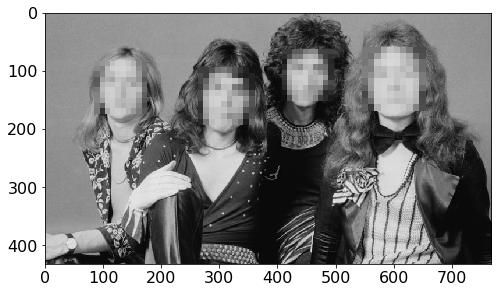

In [83]:
gray =cv2.imread(filepath+'queen.jpg')
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

for (x, y, w, h) in faces:
    face = gray[y:y+w,x:x+h]
    #face = anonymize_face_simple(face, factor=3.0)
    face = anonymize_face_pixelate(face,blocks=10)
    # store the blurred face in the output image
    gray[y:y+w,x:x+h] = face
    # cv2.rectangle(gray, (x, y), (x + w, y + h), (255, 0, 0), 2)

show(gray)

### Let's do it the modern way!

You can do the sam thing by using a pre trained neural network

In [89]:
print("[INFO] loading face detector model...")
prototxtPath = os.path.sep.join(["./face_detector", "deploy.prototxt"])
weightsPath = os.path.sep.join(["./face_detector", "res10_300x300_ssd_iter_140000.caffemodel"])
net = cv2.dnn.readNet(filepath+prototxtPath, filepath+weightsPath)

[INFO] loading face detector model...


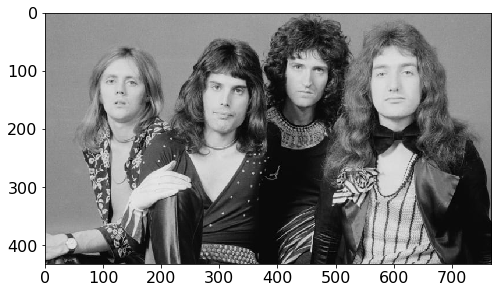

In [91]:
# load the input image from disk, clone it, and grab the image spatial
# dimensions
image = cv2.imread(filepath+'queen.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
orig = image.copy()
(h, w) = image.shape[:2]
show(image)

In [92]:
# construct a blob from the image
blob = cv2.dnn.blobFromImage(image, 1.0, (300, 300),(104.0, 177.0, 123.0))

# pass the blob through the network and obtain the face detections
print("[INFO] computing face detections...")
net.setInput(blob)
detections = net.forward()

[INFO] computing face detections...


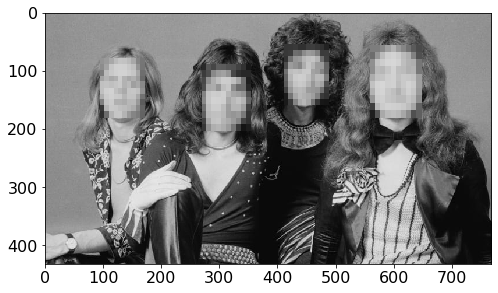

In [93]:
# loop over the detections
for i in range(0, detections.shape[2]):
    # extract the confidence (i.e., probability) associated with the
    # detection
    confidence = detections[0, 0, i, 2]

    # filter out weak detections by ensuring the confidence is greater
    # than the minimum confidence
    if confidence > 0.5:
        # compute the (x, y)-coordinates of the bounding box for the
        # object
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")

        # extract the face ROI
        face = image[startY:endY, startX:endX]
        #face = anonymize_face_simple(face, factor=3.0)
        face = anonymize_face_pixelate(face,blocks=10)

        # store the blurred face in the output image
        image[startY:endY, startX:endX] = face

show(image)